In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

sns.set_theme(style="whitegrid", palette="muted")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [37]:
ruta = "encuestaf.csv"

try:
    df = pd.read_csv(ruta)
    
except FileNotFoundError:
    print(f"No se encontró el archivo: {ruta}")
    
else:
    df = df.drop(columns=["Marca temporal", "Género", "¿Qué semestre estás cursando?", "¿Cuántos años tienes?", "expediente"], errors="ignore") # Eliminar columnas innecesarias
    
     # Ver encabezados restantes
    for i, col in enumerate(df.columns):
        print(f"{i} → {col}")



0 → Número de horas que dedicas para estudiar a la semana
1 → Promedio general del último semestre cursado
2 → Cantidad de materias aprobadas en el último semestre cursado (25-2)
3 → ¿Con cuántos lenguajes de programación trabajas con comodidad? 
4 → ¿Cuántas herramientas de IA generadoras de texto utilizas comúnmente?
5 → Generalmente, ¿considera válido el uso de la inteligencia artificial generadora de texto en trabajos académicos?
6 → Aproximadamente, ¿Cuántas veces consultas a una IA generadora de texto en un día?
7 → ¿Qué herramienta de IA generadora de texto utilizas con mayor frecuencia en tus actividades académicas?
8 → ¿Cómo calificarías tu nivel de confianza sobre las respuestas generadas por los modelos de IA generadoras de texto? [Nivel de confianza]


In [38]:
df.rename(columns={
    # ── Cuantitativas discretas ─────────────────────────
    "Cantidad de materias aprobadas en el último semestre cursado (25-2)"                                                                            : "materias_aprobadas",
    "¿Cuántas herramientas de IA generadoras de texto utilizas comúnmente?"                                                                          : "num_herramientas",
    "Aproximadamente, ¿Cuántas veces consultas a una IA generadora de texto en un día?"                                                              : "prompts_dia",
    "¿Con cuántos lenguajes de programación trabajas con comodidad? "                                                                                 : "num_lenguajes",

    # ── Cuantitativas continuas ─────────────────────────
    "Número de horas que dedicas para estudiar a la semana"                                                                                          : "horas_estudio",
    "Promedio general del último semestre cursado"                                                                                                   : "promedio",

    # ── Cualitativas nominales ──────────────────────────
    "¿Qué herramienta de IA generadora de texto utilizas con mayor frecuencia en tus actividades académicas?"                                        : "modelo_preferido",

    # ── Cualitativas ordinales ──────────────────────────
    "Generalmente, ¿considera válido el uso de la inteligencia artificial generadora de texto en trabajos académicos?"                               : "postura_ia",
    "¿Cómo calificarías tu nivel de confianza sobre las respuestas generadas por los modelos de IA generadoras de texto? [Nivel de confianza]"       : "confianza_ia",

}, inplace=True)

print("✅ Columnas renombradas")
print(df.columns.tolist())

✅ Columnas renombradas
['horas_estudio', 'promedio', 'materias_aprobadas', 'num_lenguajes', 'num_herramientas', 'postura_ia', 'prompts_dia', 'modelo_preferido', 'confianza_ia']


In [52]:
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = (
    df[col]
    .astype("string")
    .str.strip()
    .str.casefold()
    )

In [53]:
print("\n--- [1] Limpieza de Datos ---")

# Manejo de valores nulos
columnas_con_nulos = df.columns[df.isnull().any()].tolist()

for col in columnas_con_nulos:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"- Columnas limpiadas de nulos: {len(columnas_con_nulos)}")
print(f"- Registros finales: {df.shape[0]}")


--- [1] Limpieza de Datos ---
- Columnas limpiadas de nulos: 0
- Registros finales: 201


In [54]:
print(f"Registros: {df.shape[0]} encuestados, {df.shape[1]} variables\n")
df.head()        # Ver primeras 5 filas

Registros: 201 encuestados, 9 variables



,horas_estudio,promedio,materias_aprobadas,num_lenguajes,num_herramientas,postura_ia,prompts_dia,modelo_preferido,confianza_ia
0,2,96.67,3,3,2,sí,1,chatgpt,regular
1,5,91.00,5,2,3,sí,2,gemini,alto
2,5,85.00,5,1,1,sí,3,chatgpt,alto
3,8,91.00,7,3,3,sí,15,cloud,regular
4,90,97.00,7,2,2,sí,1,gemini,regular


In [55]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
horas_estudio         0
promedio              0
materias_aprobadas    0
num_lenguajes         0
num_herramientas      0
postura_ia            0
prompts_dia           0
modelo_preferido      0
confianza_ia          0
dtype: int64


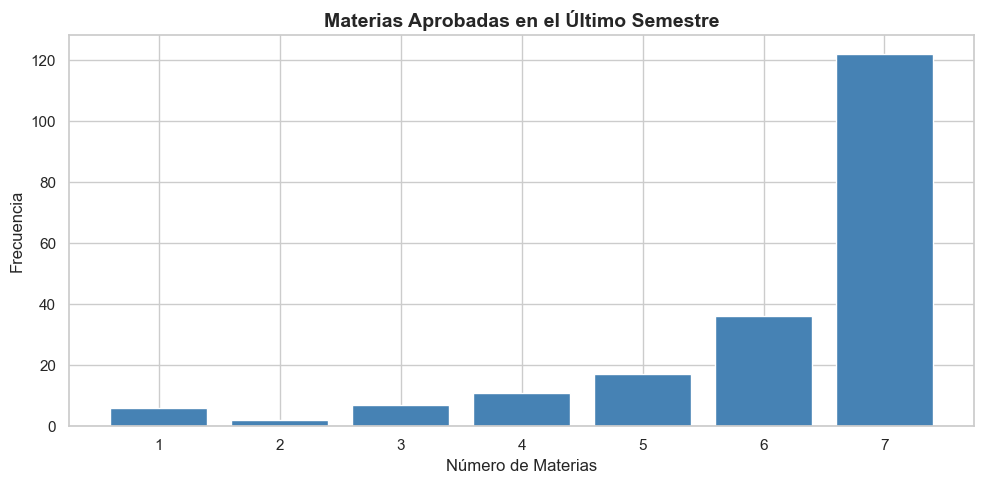

In [43]:
fig, ax = plt.subplots()
conteo = df['materias_aprobadas'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='steelblue', edgecolor='white')
ax.set_title('Materias Aprobadas en el Último Semestre', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Materias')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('materias_aprobadas.png', dpi=150)
plt.show()

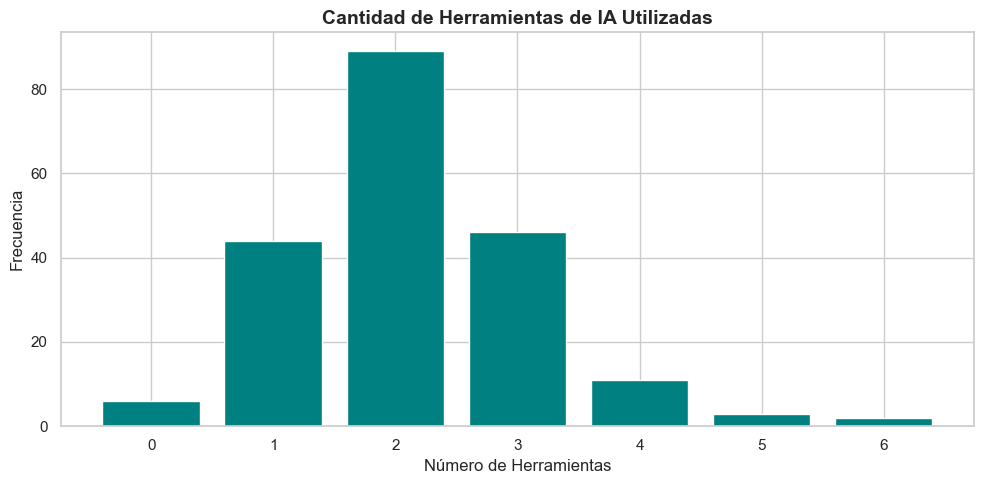

In [44]:
fig, ax = plt.subplots()
conteo = df['num_herramientas'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='teal', edgecolor='white')
ax.set_title('Cantidad de Herramientas de IA Utilizadas', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Herramientas')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('num_herramientas.png', dpi=150)
plt.show()

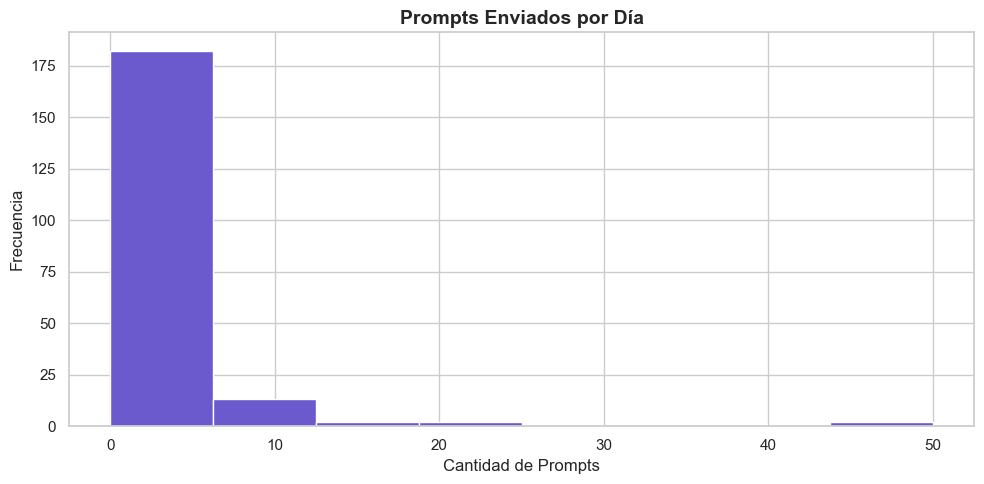

In [45]:
fig, ax = plt.subplots()
ax.hist(df['prompts_dia'], bins=8, color='slateblue', edgecolor='white')
ax.set_title('Prompts Enviados por Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Prompts')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('prompts_dia.png', dpi=150)
plt.show()

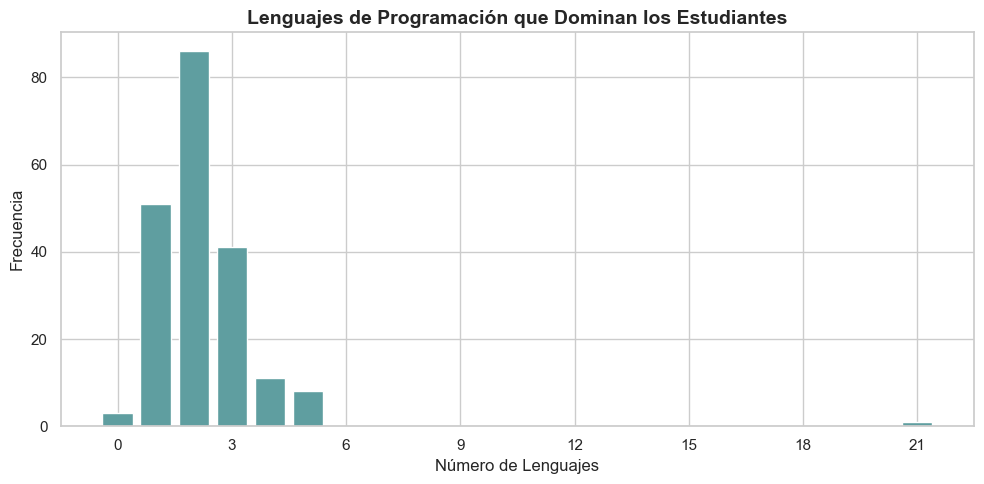

In [46]:
fig, ax = plt.subplots()
conteo = df['num_lenguajes'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='cadetblue', edgecolor='white')
ax.set_title('Lenguajes de Programación que Dominan los Estudiantes', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Lenguajes')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('num_lenguajes.png', dpi=150)
plt.show()

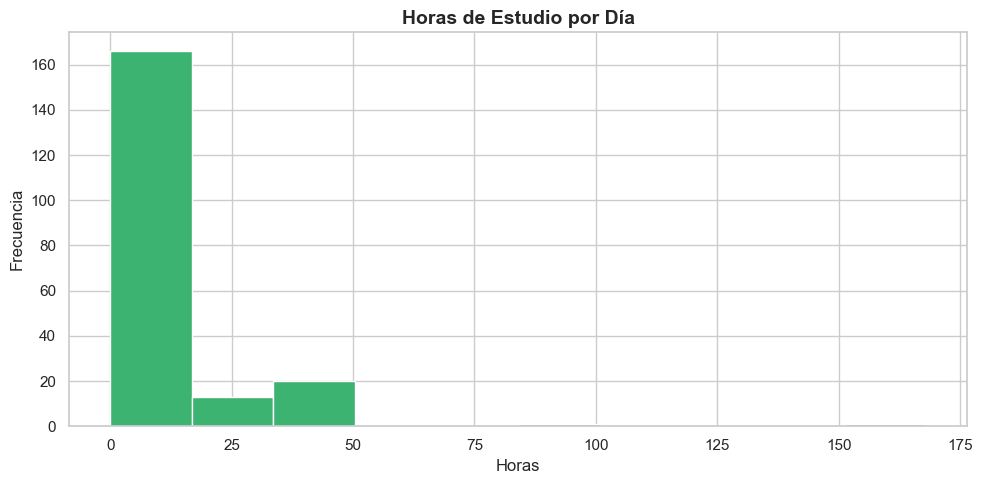

In [74]:
fig, ax = plt.subplots()
ax.hist(df['horas_estudio'], bins=10, color='mediumseagreen', edgecolor='white')
ax.set_title('Horas de Estudio por Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Horas')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('horas_estudio.png', dpi=150)
plt.show()

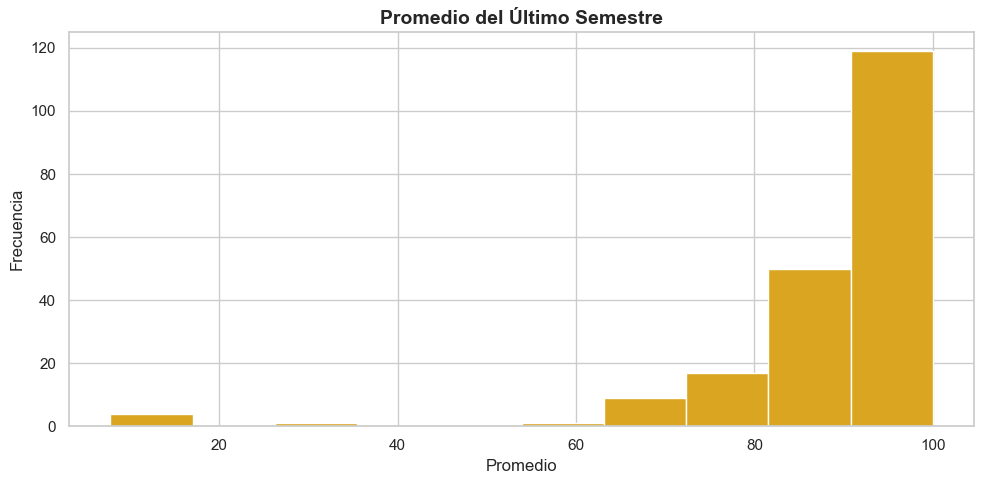

In [57]:
fig, ax = plt.subplots()
ax.hist(df['promedio'], bins=10, color='goldenrod', edgecolor='white')
ax.set_title('Promedio del Último Semestre', fontsize=14, fontweight='bold')
ax.set_xlabel('Promedio')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('promedio.png', dpi=150)
plt.show()


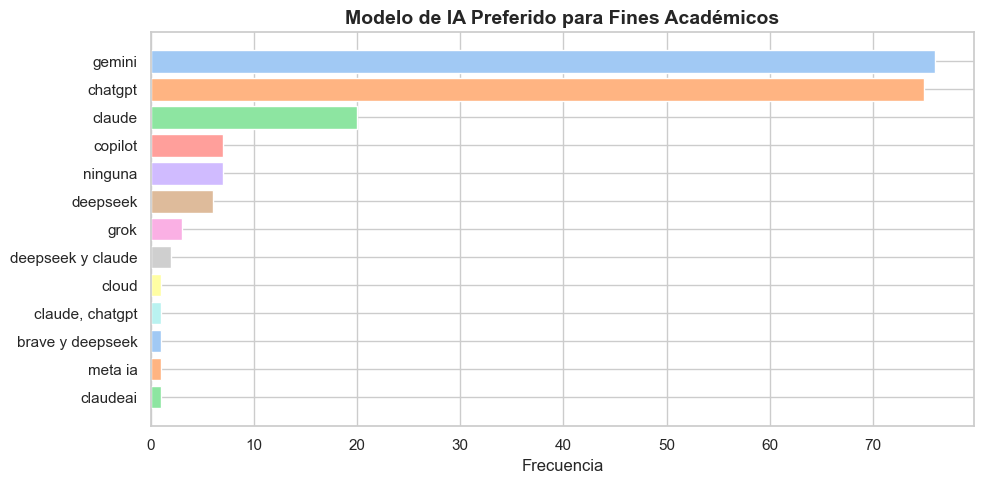

In [56]:
fig, ax = plt.subplots()
conteo = df['modelo_preferido'].value_counts()
ax.barh(conteo.index, conteo.values, color=sns.color_palette("pastel", len(conteo)))
ax.set_title('Modelo de IA Preferido para Fines Académicos', fontsize=14, fontweight='bold')
ax.set_xlabel('Frecuencia')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('modelo_preferido.png', dpi=150)
plt.show()

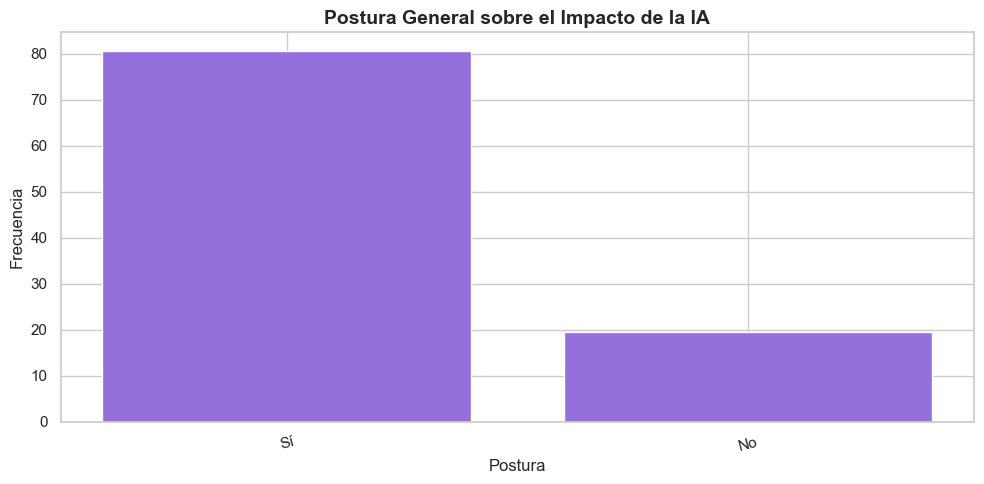

In [75]:
orden_postura = ['sí', 'no']
fig, ax = plt.subplots()

conteo = df['postura_ia'].value_counts(normalize=True) * 100
conteo = conteo.reindex(orden_postura, fill_value=0)

etiquetas = ['Sí', 'No']
ax.bar(etiquetas, conteo.values, color='mediumpurple', edgecolor='white')
ax.set_title('Postura General sobre el Impacto de la IA', fontsize=14, fontweight='bold')
ax.set_xlabel('Postura')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('postura_ia.png', dpi=150)
plt.show()

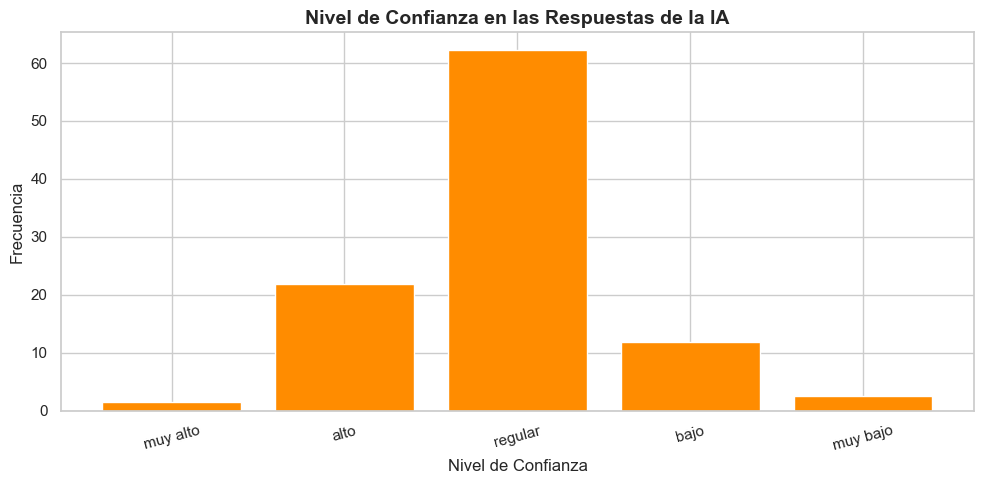

In [76]:
orden_confianza = ['muy alto', 'alto', 'regular', 'bajo', 'muy bajo']
fig, ax = plt.subplots()
conteo = df['confianza_ia'].value_counts(normalize=True) * 100
conteo = conteo.reindex(orden_confianza, fill_value=0)
ax.bar(conteo.index, conteo.values, color='darkorange', edgecolor='white')
ax.set_title('Nivel de Confianza en las Respuestas de la IA', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Confianza')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('confianza_ia.png', dpi=150)
plt.show()

In [ ]:
print("\n---Resumen Descriptivo ---")
resumen = df.describe(include='all').T
print(resumen)


--- [2] Resumen Descriptivo ---
                    count unique      top freq       mean        std  min  \
horas_estudio       201.0    NaN      NaN  NaN  11.114428  17.212549  0.0   
promedio            201.0    NaN      NaN  NaN  88.787214  14.621711  7.8   
materias_aprobadas  201.0    NaN      NaN  NaN   6.119403   1.457968  1.0   
num_lenguajes       201.0    NaN      NaN  NaN   2.243781   1.686794  0.0   
num_herramientas    201.0    NaN      NaN  NaN   2.144279   1.031542  0.0   
postura_ia            201      2       sí  162        NaN        NaN  NaN   
prompts_dia         201.0    NaN      NaN  NaN   3.771144   5.568426  0.0   
modelo_preferido      201     13   gemini   76        NaN        NaN  NaN   
confianza_ia          201      5  regular  125        NaN        NaN  NaN   

                     25%   50%   75%    max  
horas_estudio        3.0   5.0  10.0  168.0  
promedio            86.0  92.0  97.0  100.0  
materias_aprobadas   6.0   7.0   7.0    7.0  
num_lenguaje


--- [3] Matriz de Correlación (Pearson) ---
                    horas_estudio  promedio  materias_aprobadas  \
horas_estudio            1.000000  0.114434            0.080344   
promedio                 0.114434  1.000000            0.230225   
materias_aprobadas       0.080344  0.230225            1.000000   
num_lenguajes            0.109422  0.158387            0.059264   
num_herramientas         0.066087  0.000239           -0.004863   
prompts_dia              0.264029  0.016488            0.030481   

                    num_lenguajes  num_herramientas  prompts_dia  
horas_estudio            0.109422          0.066087     0.264029  
promedio                 0.158387          0.000239     0.016488  
materias_aprobadas       0.059264         -0.004863     0.030481  
num_lenguajes            1.000000          0.034283     0.081559  
num_herramientas         0.034283          1.000000     0.205113  
prompts_dia              0.081559          0.205113     1.000000  


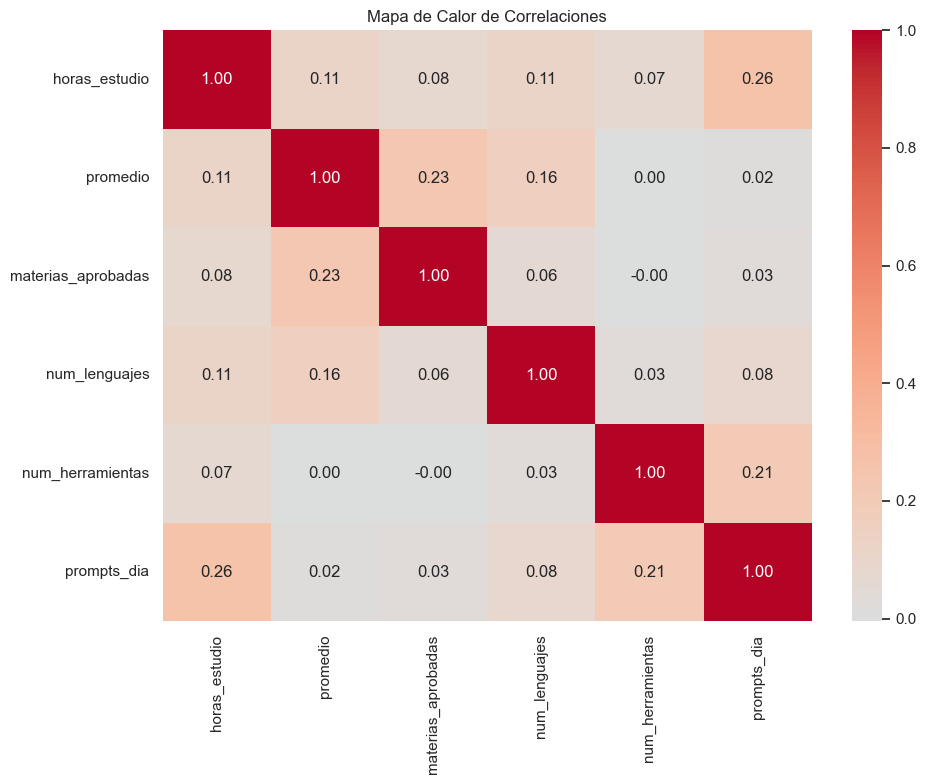

In [ ]:
    #  Análisis de Correlación
print("\n---Matriz de Correlación (Pearson) ---")
numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty and numeric_df.shape[1] > 1:
    corr_matrix = numeric_df.corr()
    print(corr_matrix)

    # Visualización: Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title("Mapa de Calor de Correlaciones")
    plt.tight_layout()
    plt.savefig('mapa_correlacion.png', dpi=150)
    plt.show()
else:
    print("! Nota: No hay suficientes columnas numéricas para correlacionar.")



--- [4] Generando Histogramas ---


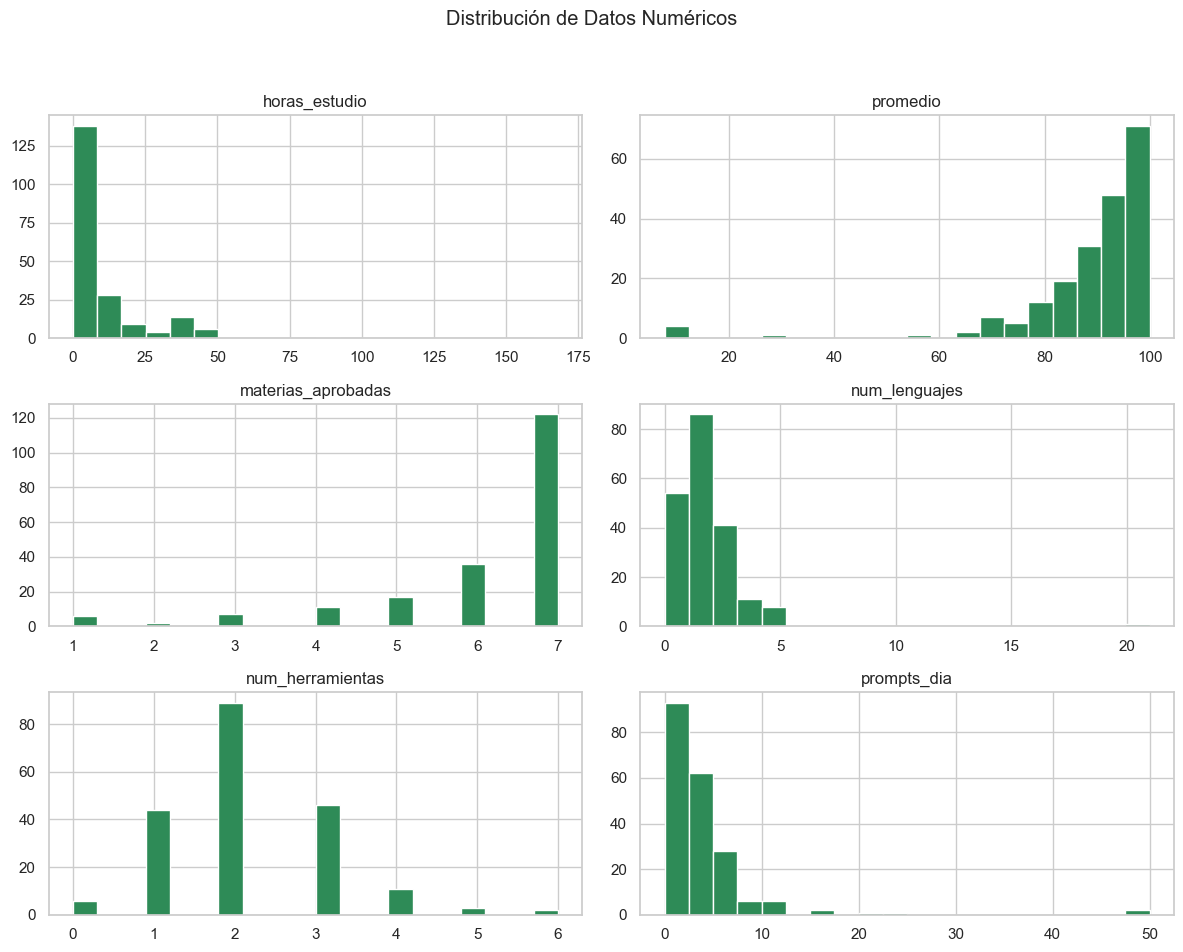

In [71]:
    #  Visualización de Distribuciones
print("\n--- [4] Generando Histogramas ---")
if not numeric_df.empty:
    numeric_df.hist(bins=20, figsize=(12, 10), color='seagreen', edgecolor='white')
    plt.suptitle("Distribución de Datos Numéricos")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [72]:
# ── Estadística Descriptiva - Variables Cuantitativas ──
cuantitativas = ['materias_aprobadas', 'num_herramientas', 'prompts_dia', 'num_lenguajes', 'horas_estudio', 'promedio']

# Calcular cada métrica
tabla = pd.DataFrame({
    'Media'              : df[cuantitativas].mean().round(2),
    'Mediana'            : df[cuantitativas].median().round(2),
    'Moda'               : df[cuantitativas].mode().iloc[0].round(2),
    'Varianza'           : df[cuantitativas].var().round(2),
    'Desv. Estándar'     : df[cuantitativas].std().round(2),
    'Mínimo'             : df[cuantitativas].min(),
    'Máximo'             : df[cuantitativas].max(),
})

print("Estadística Descriptiva - Variables Cuantitativas\n")
print(tabla.to_string())

Estadística Descriptiva - Variables Cuantitativas

                    Media  Mediana  Moda  Varianza  Desv. Estándar  Mínimo  Máximo
materias_aprobadas   6.12      7.0   7.0      2.13            1.46     1.0     7.0
num_herramientas     2.14      2.0   2.0      1.06            1.03     0.0     6.0
prompts_dia          3.77      3.0   2.0     31.01            5.57     0.0    50.0
num_lenguajes        2.24      2.0   2.0      2.85            1.69     0.0    21.0
horas_estudio       11.11      5.0   5.0    296.27           17.21     0.0   168.0
promedio            88.79     92.0  90.0    213.79           14.62     7.8   100.0
